In [1]:
import joblib
import pandas as pd
import xgboost as xgb
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
!uv add shap

Resolved 171 packages in 0.57ms
Audited 167 packages in 0.05ms


In [3]:
import shap

/home/edyn/Escritorio/project_edyN/MLEngineer/mle-III/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Métodos globales

## Feature Importance

In [4]:
# Normalizar importancias de features entre 0 y 1
def normalize_feature_importance(feature_names, feature_importances):
    # Obtener el vector de importancias desde el modelo (array)
    # feature_importances = importances  # array de importancias por feature

    # Calcular el mínimo de las importancias (usado para escalar)
    min_imp = np.min(feature_importances)  # mínimo valor en feature_importances

    # Calcular el máximo de las importancias (usado para escalar)
    max_imp = np.max(feature_importances)  # máximo valor en feature_importances

    # Evitar división por cero en caso de que todas las importancias sean iguales
    denom = max_imp - min_imp if (max_imp - min_imp) != 0 else 1.0  # denominador seguro

    # Normalizar cada importancia al rango [0, 1]
    normalized_features_importance = (feature_importances - min_imp) / denom  # vector normalizado

    # Construir DataFrame con nombres de features y sus puntuaciones normalizadas
    importance_df = pd.DataFrame(
        {
            "Features": feature_names,                      # lista de nombres de features usados en el modelo
            "importance": normalized_features_importance   # puntuaciones normalizadas correspondientes
        }
    ).sort_values(by="importance", ascending=False)        # ordenar de mayor a menor importancia
    return importance_df

In [5]:
def barplot_feature_importance(importance_df, n_head=None):
    plt.figure(figsize=(12, 8))
    sns.barplot(y='Features', x='importance', data=importance_df.head(n_head))
    plt.title('Importancia de características')
    plt.xlabel('Importancia')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.savefig("../docs/images/feature_importance_XGBClassifier.png")
    plt.show()

## SHAP

In [21]:
def shap_summary_plot(values, X_sample, feature_names, type_graph=None):
    if type_graph == 'bar':
        shap.summary_plot(values, X_sample, feature_names, plot_type=type_graph)
    else:
        shap.summary_plot(values, X_sample, feature_names, show=False)
        plt.savefig("../docs/images/shap_summary_XGBClassifier.png", dpi=150)

# Métodos locales

## SHAP

In [7]:
def forceplot_by_instance(explainer, shap_values, feature_names, instance_row=0):
    # crea un force_plot para la instancia i
    shap.force_plot(
        explainer.expected_value,
        shap_values.values[instance_row, :],
        feature_names=feature_names,
        matplotlib=True
    )

# Interpretabilidad

In [8]:
DATA_PATH = Path.cwd().parent / "data" / "interim"

X_train = joblib.load(DATA_PATH / "X_train.pkl")
X_test = joblib.load(DATA_PATH / "X_test.pkl")

In [9]:
MODELS_DIR = Path.cwd().parent / "models"

pipeline_xgb = joblib.load(MODELS_DIR / "XGBClassifier-300_pipeline.pkl")

# Extraer el preprocesador y el modelo desde el pipeline
preprocessor = pipeline_xgb.named_steps["preprocessor"]
model = pipeline_xgb.named_steps["model"]

# Transformar los datos de entrada
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [10]:
# Obtener los nombres de las columnas transformadas
feature_names = pipeline_xgb.named_steps["preprocessor"].get_feature_names_out()

# Extraer importancias del modelo
feature_importances = pipeline_xgb.named_steps["model"].feature_importances_

## Normalizar importancia de características

In [11]:
importance_df = normalize_feature_importance(feature_names, feature_importances)
importance_df.head(10)

,Features,importance
44,cat__poutcome_success,1.000000
42,cat__poutcome_failure,0.452833
2,num__duration,0.379030
37,cat__month_mar,0.330484
24,cat__housing_no,0.293369
40,cat__month_oct,0.269920
30,cat__month_apr,0.215329
41,cat__month_sep,0.189244
38,cat__month_may,0.180732
25,cat__housing_yes,0.168853


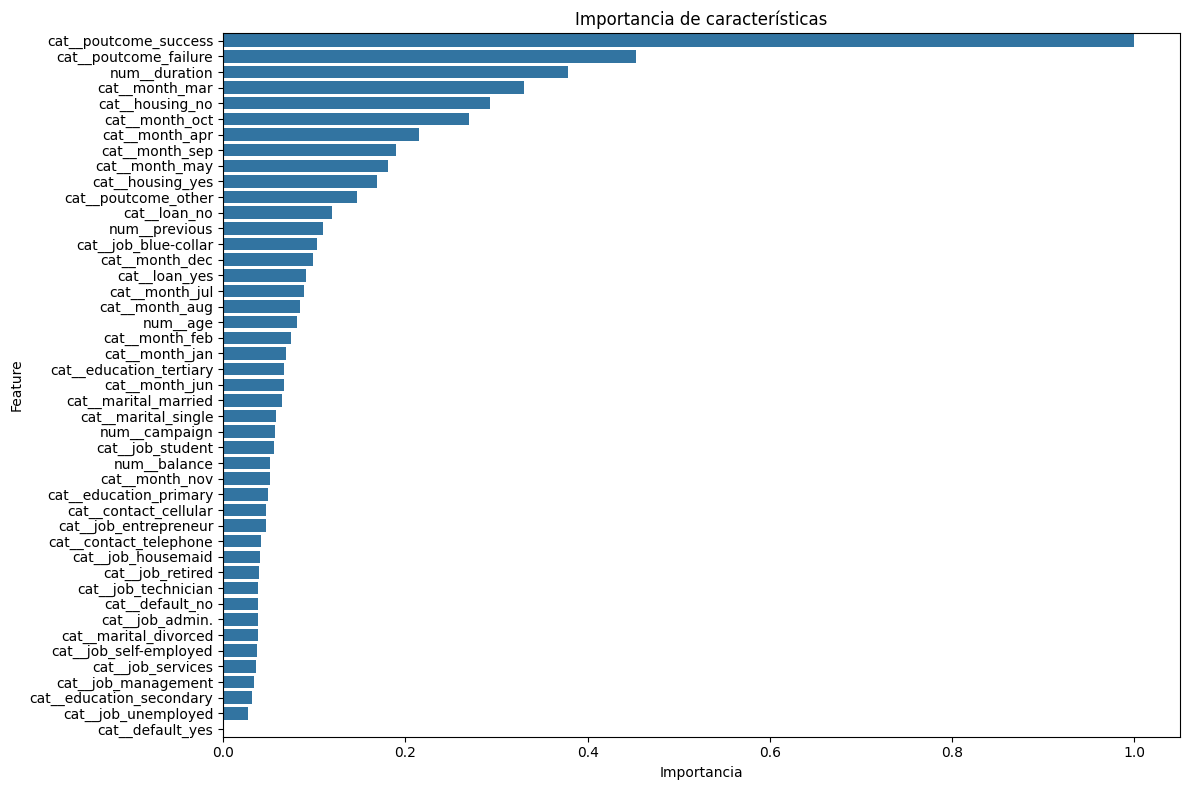

In [12]:
barplot_feature_importance(importance_df)

## Visualizar efecto de cada variable en la predicción de determinado registro

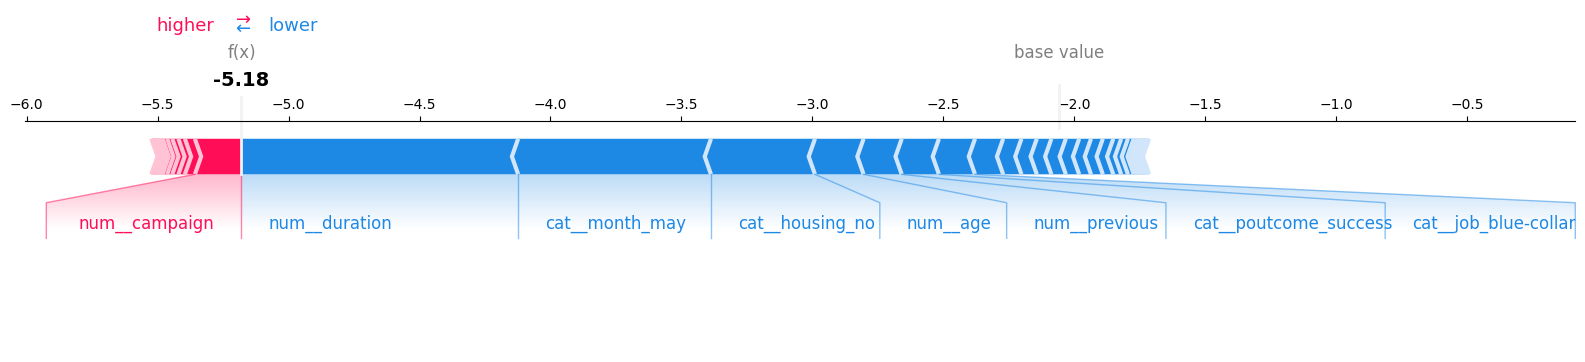

In [13]:
# Crear el explainer basado en el modelo del pipeline
explainer = shap.Explainer(pipeline_xgb.named_steps["model"])

# Calcular los SHAP values usando los datos transformados
shap_values = explainer(X_test_transformed)

forceplot_by_instance(explainer, shap_values, feature_names, 0)

### Visualizar efecto en caso positivo

In [14]:
y_test = joblib.load(DATA_PATH / "y_test.pkl")
X_test[y_test == 1]

,age,balance,duration,campaign,previous,job,marital,education,default,housing,loan,contact,month,poutcome
34145,33,498,301,1,0,blue-collar,single,secondary,no,no,no,cellular,apr,failure
31271,31,883,112,2,1,management,divorced,tertiary,no,yes,no,cellular,mar,failure
41828,30,536,244,1,1,management,single,tertiary,no,no,no,cellular,oct,success
34197,33,5437,267,1,1,management,single,tertiary,no,no,no,cellular,may,failure
35078,35,991,1489,3,0,management,married,tertiary,no,yes,no,cellular,may,failure
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24921,41,8491,929,1,0,entrepreneur,married,secondary,no,yes,no,cellular,nov,failure
43042,45,226,91,4,6,management,married,tertiary,no,yes,no,cellular,feb,success
42774,36,3949,130,2,0,management,married,tertiary,no,no,no,cellular,jan,failure
42431,45,0,344,1,0,technician,married,secondary,no,yes,no,cellular,dec,failure


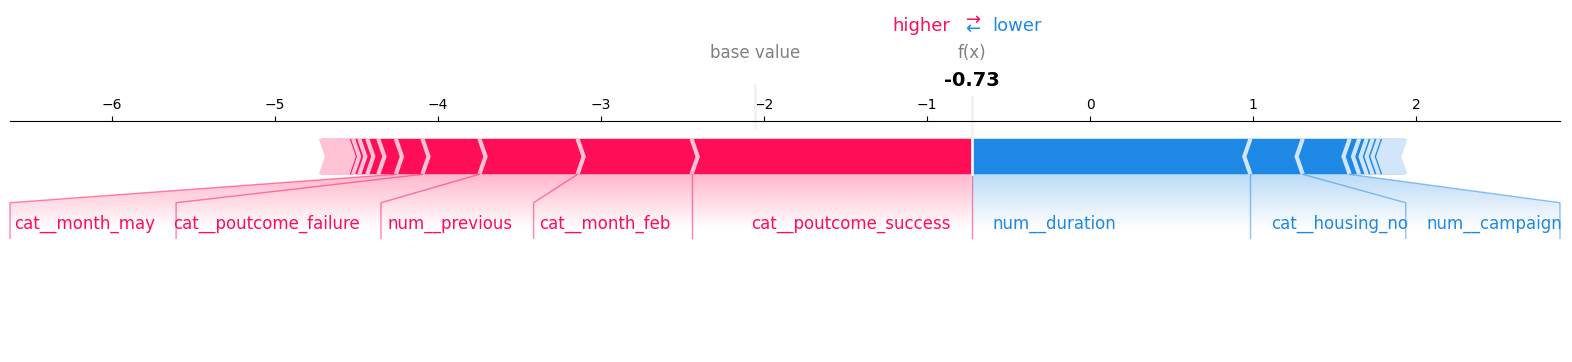

In [15]:
INSTANCE_ROW = X_test.index.get_loc(43042)

forceplot_by_instance(explainer, shap_values, feature_names, INSTANCE_ROW)

## Visualizar la contribución de cada feature en conjunto

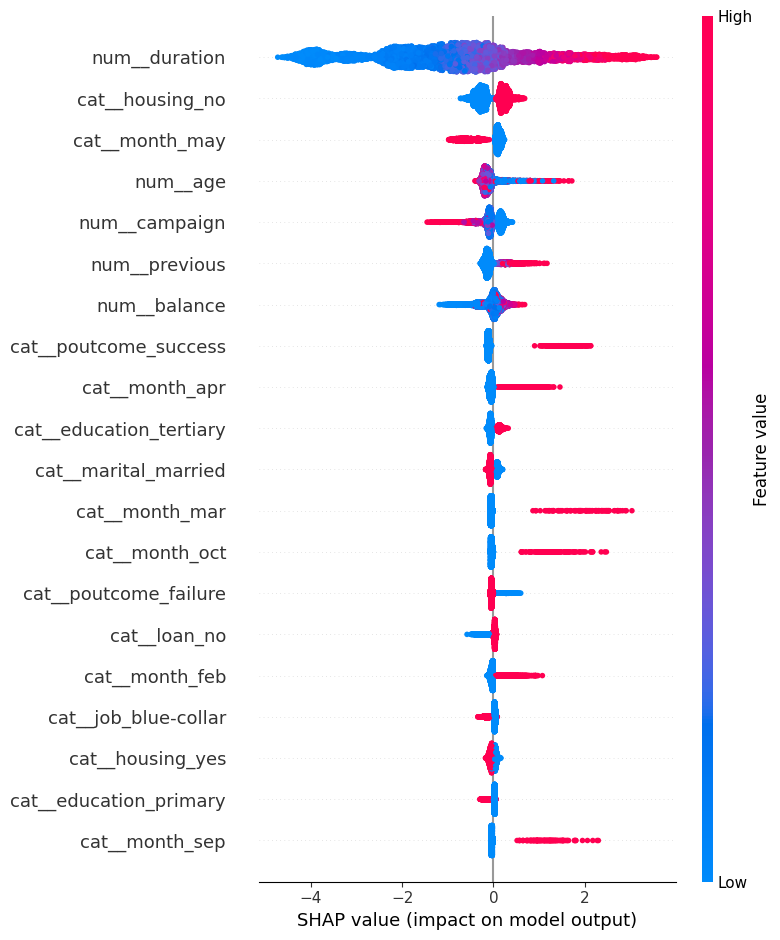

In [22]:
shap_summary_plot(values=shap_values, X_sample=X_test_transformed, feature_names=feature_names)

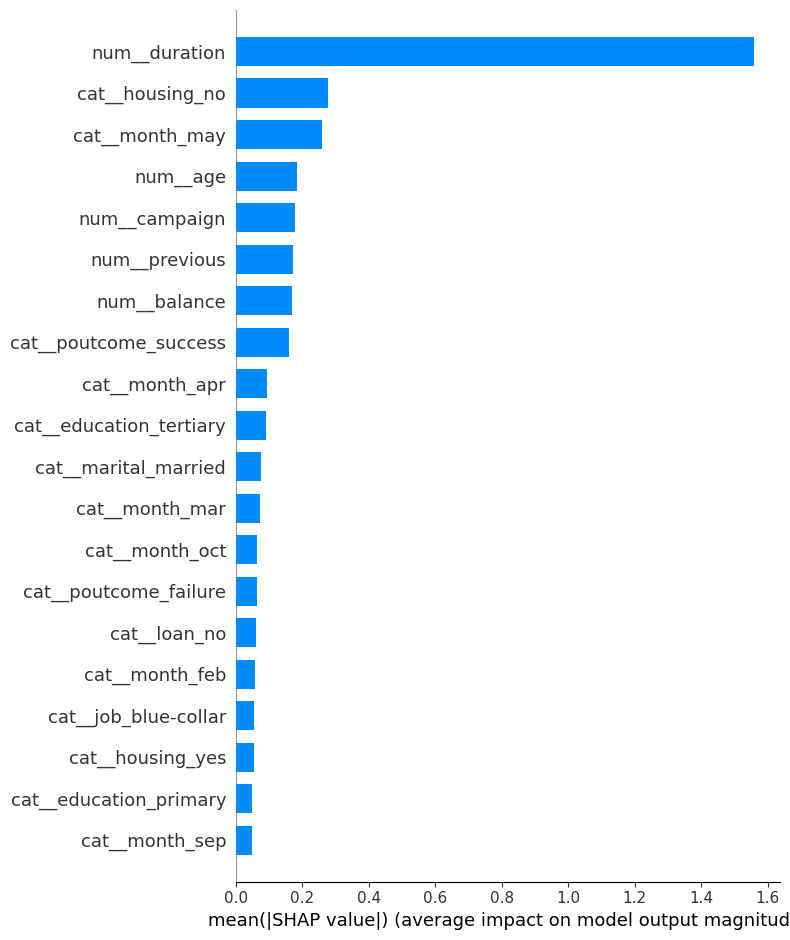

<Figure size 640x480 with 0 Axes>

In [17]:
# Gráfico de barras (importancia media absoluta)
shap_summary_plot(values=shap_values, X_sample=X_test_transformed, feature_names=feature_names, type_graph='bar')

In [20]:
# alternativa para visualizar múltiples instancias
shap.initjs()
shap.plots.force(explainer.expected_value, shap_values.values[:500])